# 05 — Backpropagation from scratch: every derivative on one real sample

This notebook is the mechanical heart of ANN learning. We use the same **4 → 2 → 1** network and one real digit-derived sample so every gradient can be inspected.

## What you should learn
- forward values and backward sensitivities are different quantities;
- chain rule composes local derivatives;
- how gradients reach output weights, hidden activations, hidden pre-activations, input weights, and biases;
- how one gradient-descent update changes the next forward pass;
- how numerical gradient checking validates manual backprop.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

from sklearn.datasets import load_digits
d=load_digits();img=d.images[3];digit=int(d.target[3]);y=np.array([[digit%2]],dtype=float)
x=np.array([img[:4,:].sum(),img[4:,:].sum(),img[:,:4].sum(),img[:,4:].sum()],dtype=float).reshape(1,-1)/200.0
W1=np.array([[.20,-.10],[-.30,.50],[.10,.20],[.40,-.20]])
b1=np.array([[.10,-.20]])
W2=np.array([[1.20],[-.90]]);b2=np.array([[.05]])
sigmoid=lambda v:1/(1+np.exp(-v))


## 1. Forward pass ledger


In [2]:
z1=x@W1+b1
a1=np.tanh(z1)
z2=a1@W2+b2
yhat=sigmoid(z2)
eps=1e-9
loss=-(y*np.log(yhat+eps)+(1-y)*np.log(1-yhat+eps)).mean()
print('digit=',digit,'target odd/even y=',y.item())
print('x =',x)
print('z1=',z1,'a1=',a1,'z2=',z2,'yhat=',yhat.item(),'loss=',loss)


digit= 3 target odd/even y= 1.0
x = [[0.7   0.635 0.575 0.76 ]]
z1= [[0.411  0.0105]] a1= [[0.38932 0.0105 ]] z2= [[0.50774]] yhat= 0.6242756076644749 loss= 0.47116332757280965


## 2. Backward pass, line by line
For sigmoid + BCE:

$$d z^{(2)}=\hat y-y$$

Then:

$$dW^{(2)}=(a^{(1)})^T dz^{(2)}$$
$$da^{(1)}=dz^{(2)}(W^{(2)})^T$$
$$dz^{(1)}=da^{(1)}\odot(1-\tanh^2(z^{(1)}))$$
$$dW^{(1)}=x^Tdz^{(1)}$$


In [3]:
dz2=yhat-y
dW2=a1.T@dz2
db2=dz2.copy()
da1=dz2@W2.T
dz1=da1*(1-a1**2)
dW1=x.T@dz1
db1=dz1.copy()
items=[('dz2',dz2),('dW2',dW2),('db2',db2),('da1',da1),('dz1',dz1),('dW1',dW1),('db1',db1)]
for name,val in items: print(f'{name} shape={val.shape}\n{val}\n')


dz2 shape=(1, 1)
[[-0.37572]]

dW2 shape=(2, 1)
[[-0.14628]
 [-0.00394]]

db2 shape=(1, 1)
[[-0.37572]]

da1 shape=(1, 2)
[[-0.45087  0.33815]]

dz1 shape=(1, 2)
[[-0.38253  0.33811]]

dW1 shape=(4, 2)
[[-0.26777  0.23668]
 [-0.24291  0.2147 ]
 [-0.21996  0.19442]
 [-0.29072  0.25697]]

db1 shape=(1, 2)
[[-0.38253  0.33811]]



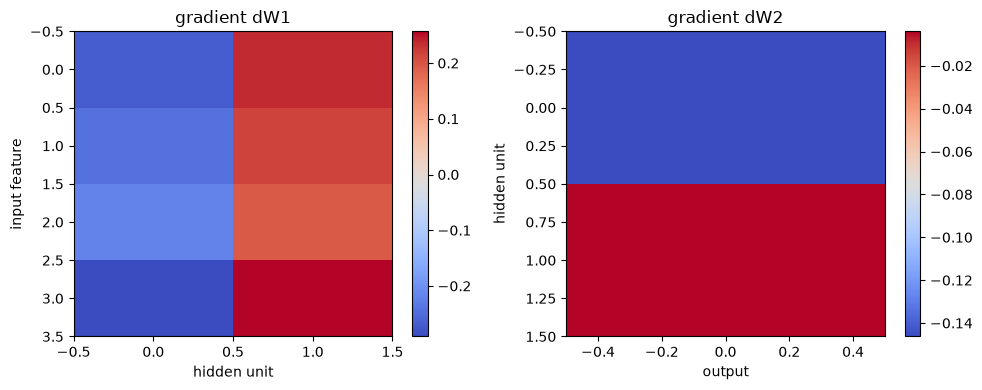

In [4]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
im=axes[0].imshow(dW1,cmap='coolwarm',aspect='auto');axes[0].set_title('gradient dW1');axes[0].set_xlabel('hidden unit');axes[0].set_ylabel('input feature');plt.colorbar(im,ax=axes[0])
im2=axes[1].imshow(dW2,cmap='coolwarm',aspect='auto');axes[1].set_title('gradient dW2');axes[1].set_xlabel('output');axes[1].set_ylabel('hidden unit');plt.colorbar(im2,ax=axes[1]);plt.tight_layout();plt.show()


### What does a gradient value mean?
If $dW_{ij}=+0.08$, a tiny increase in that weight would increase loss. Gradient descent therefore subtracts a positive amount. If it is negative, subtracting it increases the parameter.


## 3. One update, then forward again


In [5]:
lr=.1
W1n=W1-lr*dW1;b1n=b1-lr*db1;W2n=W2-lr*dW2;b2n=b2-lr*db2
z1n=x@W1n+b1n;a1n=np.tanh(z1n);z2n=a1n@W2n+b2n;yhatn=sigmoid(z2n)
lossn=-(y*np.log(yhatn+eps)+(1-y)*np.log(1-yhatn+eps)).mean()
print(f'before: prediction={yhat.item():.6f}, loss={loss:.6f}')
print(f'after : prediction={yhatn.item():.6f}, loss={lossn:.6f}')
print('hidden representation before:',a1)
print('hidden representation after :',a1n)


before: prediction=0.624276, loss=0.471163
after : prediction=0.677360, loss=0.389553
hidden representation before: [[0.38932 0.0105 ]]
hidden representation after : [[ 0.47628 -0.08402]]


Notice what changed: **the same input now has different hidden coordinates** because the weights changed. That is representation learning at the single-update level.


## 4. Numerical gradient check
A robust implementation should not merely *look* correct. We perturb each parameter and compare finite-difference gradients with backprop.


In [6]:
def one_loss(W1_,b1_,W2_,b2_):
    h=np.tanh(x@W1_+b1_);p=sigmoid(h@W2_+b2_)
    return float(-(y*np.log(p+eps)+(1-y)*np.log(1-p+eps)).mean())
def numeric_at(arr,index,setter,h=1e-5):
    plus=arr.copy();minus=arr.copy();plus[index]+=h;minus[index]-=h
    return (setter(plus)-setter(minus))/(2*h)
checks=[]
for idx in np.ndindex(W1.shape):
    num=numeric_at(W1,idx,lambda v:one_loss(v,b1,W2,b2));checks.append(('W1'+str(idx),dW1[idx],num))
for idx in np.ndindex(W2.shape):
    num=numeric_at(W2,idx,lambda v:one_loss(W1,b1,v,b2));checks.append(('W2'+str(idx),dW2[idx],num))
check_df=pd.DataFrame(checks,columns=['parameter','backprop','finite difference']);check_df['abs diff']=abs(check_df.backprop-check_df['finite difference']);check_df


,parameter,backprop,finite difference,abs diff
0,"W1(0, 0)",-0.267771,-0.267771,4.263483e-10
1,"W1(0, 1)",0.236680,0.236680,3.756364e-10
2,"W1(1, 0)",-0.242907,-0.242907,3.952441e-10
3,"W1(1, 1)",0.214703,0.214703,3.536028e-10
4,"W1(2, 0)",-0.219955,-0.219955,3.462496e-10
5,"W1(2, 1)",0.194416,0.194416,3.121270e-10
6,"W1(3, 0)",-0.290723,-0.290723,4.670161e-10
7,"W1(3, 1)",0.256967,0.256967,4.143365e-10
8,"W2(0, 0)",-0.146278,-0.146278,2.322643e-10
9,"W2(1, 0)",-0.003945,-0.003945,4.953002e-12


## Inference / insight
Backpropagation is not “the network thinking backward.” It is **reverse-mode differentiation**: reuse the forward computational graph to efficiently compute how one scalar loss depends on many parameters.
